<a href="https://colab.research.google.com/github/worgen25/Notas-Bootcamp-Data-Analyst-2026/blob/main/Sprint_7_CH3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🧩 Conclusión
Términos clave
Outliers o valores atípicos: Valores que se alejan significativamente del comportamiento general de los datos.

IQR: Medida de dispersión que indica el rango donde se encuentra el 50% central de los datos.

Z-Score: Indica cuántas desviaciones estándar está un dato por encima o por debajo de la media.

Regla 1.5 × IQR: Método que marca como atípicos los valores que quedan por debajo de Q1 − 1.5×IQR o por encima de Q3 + 1.5×IQR.

Regla |z| > 3: Considera atípicos los valores cuyo puntaje Z es mayor a 3 o menor a −3 en términos absolutos.

#Ideas clave
No existe un único método perfecto.

Las distribuciones sesgadas requieren IQR.

Las distribuciones simétricas permiten z-score.

Detectar outliers siempre inicia una interpretación de negocio, no una eliminación automática.



#El método del Rango Intercuartílico (IQR)

 es una técnica estadística robusta para medir la dispersión y detectar valores atípicos (outliers) en un conjunto de datos.

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# calcular Q1, Q3 e IQR
Q1 = df['order_value'].quantile(0.25)
Q3 = df['order_value'].quantile(0.75)
IQR = Q3 - Q1       #calculo de el iqr


# calcular límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR         #el 1.5 es por la formula nata de el iqr
limite_superior = Q3 + 1.5 * IQR

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df[df['order_value'] < limite_inferior])

print("\nRegistros arriba del límite superior")
print(df[df['order_value'] > limite_superior])

#Z score
El Z-Score (o puntuación Z) mide cuántas desviaciones estándar se aleja un valor de la media. Es como preguntarse: "¿qué tan raro o extremo es este valor comparado con el resto?"

Regla práctica: Si |Z-Score| > 3, es un outlier (solo 0.3% de los datos están tan lejos de la media).


In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# ----- IQR -----
# calcular Q1, Q3 e IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# calcular límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df['price'].mean()
std = df['price'].std()
df['z'] = (df['price'] - mean) / std      #CALCULO DEL Z SCORE

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print(df[(df['price'] < lower) | (df['price'] > upper)])

print('\nOutliers usando Z-Score:')
print(df[df['z'].abs() > 3])

#¿Cuál es mejor para tu análisis?
Depende de tu objetivo:


1.   IQR: Mejor para encontrar propiedades "inusuales" en el mercado general
2.   Z-Score: Mejor para encontrar propiedades "extremadamente raras"

_______________________________________________________________________


# 🛠️ ¿Qué es la Winsorización?
La winsorización es una técnica estadística que reduce el impacto de valores atípicos (outliers) limitando sus valores extremos a un percentil específico (generalmente 1% o 99%) en lugar de eliminarlos

No los eliminas, sino que los mueves a un límite razonable.

 #Metodos
 * Mantener outliers (KEEP)

Cuando representan un comportamiento real:

1. Clientes "whales" o de alto valor (order_value altos reales).
2. Productos premium con precios elevados.
3. Ventas grandes por fecha especial (Navidad, Black Friday).
4. Mantener datos es esencial para segmentación, cálculo de revenue e identificación de clientes valiosos.


*   🗑️ Eliminar outliers (DROP)

1. El valor es imposible:
2. quantity <= 0 (errores intencionales en el dataset).
3. customer_age = -999 (sentinel corrupto).
4. order_date en 2026 (errores documentados).
5. Valores cuya presencia distorsionaría completamente el análisis sin aportar interpretación real.

*✂️ Capar o Winsorizar (CAP/WINSORIZE)
Cuando:

1. El valor extremo es posible, pero muy raro.
2. El análisis estadístico requiere moderar su impacto sin eliminarlos.
3. Necesitas estabilizar métricas (mean, std) para modelos o informes.

In [ ]:
import pandas as pd
import numpy as np

# Cargar datos
df = pd.read_csv("/datasets/everpeak_clean.csv")

# Calcular percentiles 1 y 99
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

# Winsorizar usando clip()
df['price_winsor'] = df['price'].clip(lower=lower, upper=upper)

print(f"Percentil 1: {lower}")
print(f"Percentil 99: {upper}")
print(df[['price', 'price_winsor']].describe())


#Segmentación para el análisis de clientes

 ¿Qué es Feature Engineering?
La ingeniería de características (Feature Engineering) consiste en crear, transformar o combinar columnas para que el análisis o un modelo entiendan mejor el comportamiento del negocio.

En otras palabras, es convertir datos crudos en variables más informativas.

Ejemplos comunes:

Crear categorías a partir de rangos numéricos (edad → “jóvenes”, “adultos”).
Sumar transacciones individuales para calcular gasto anual.
Crear indicadores (flags).
Combinar columnas para generar ratios (ingresos/visitas).
Estas nuevas columnas no existían originalmente, pero permiten revelar patrones clave.

Para realizar la segmentacion puede hacerse de dos maneras:

1. utilizando np.where
2. utilizando una funcion personalizada

ej:se requiere utilizar la siguiente asignacion para los clientes con una funcion...

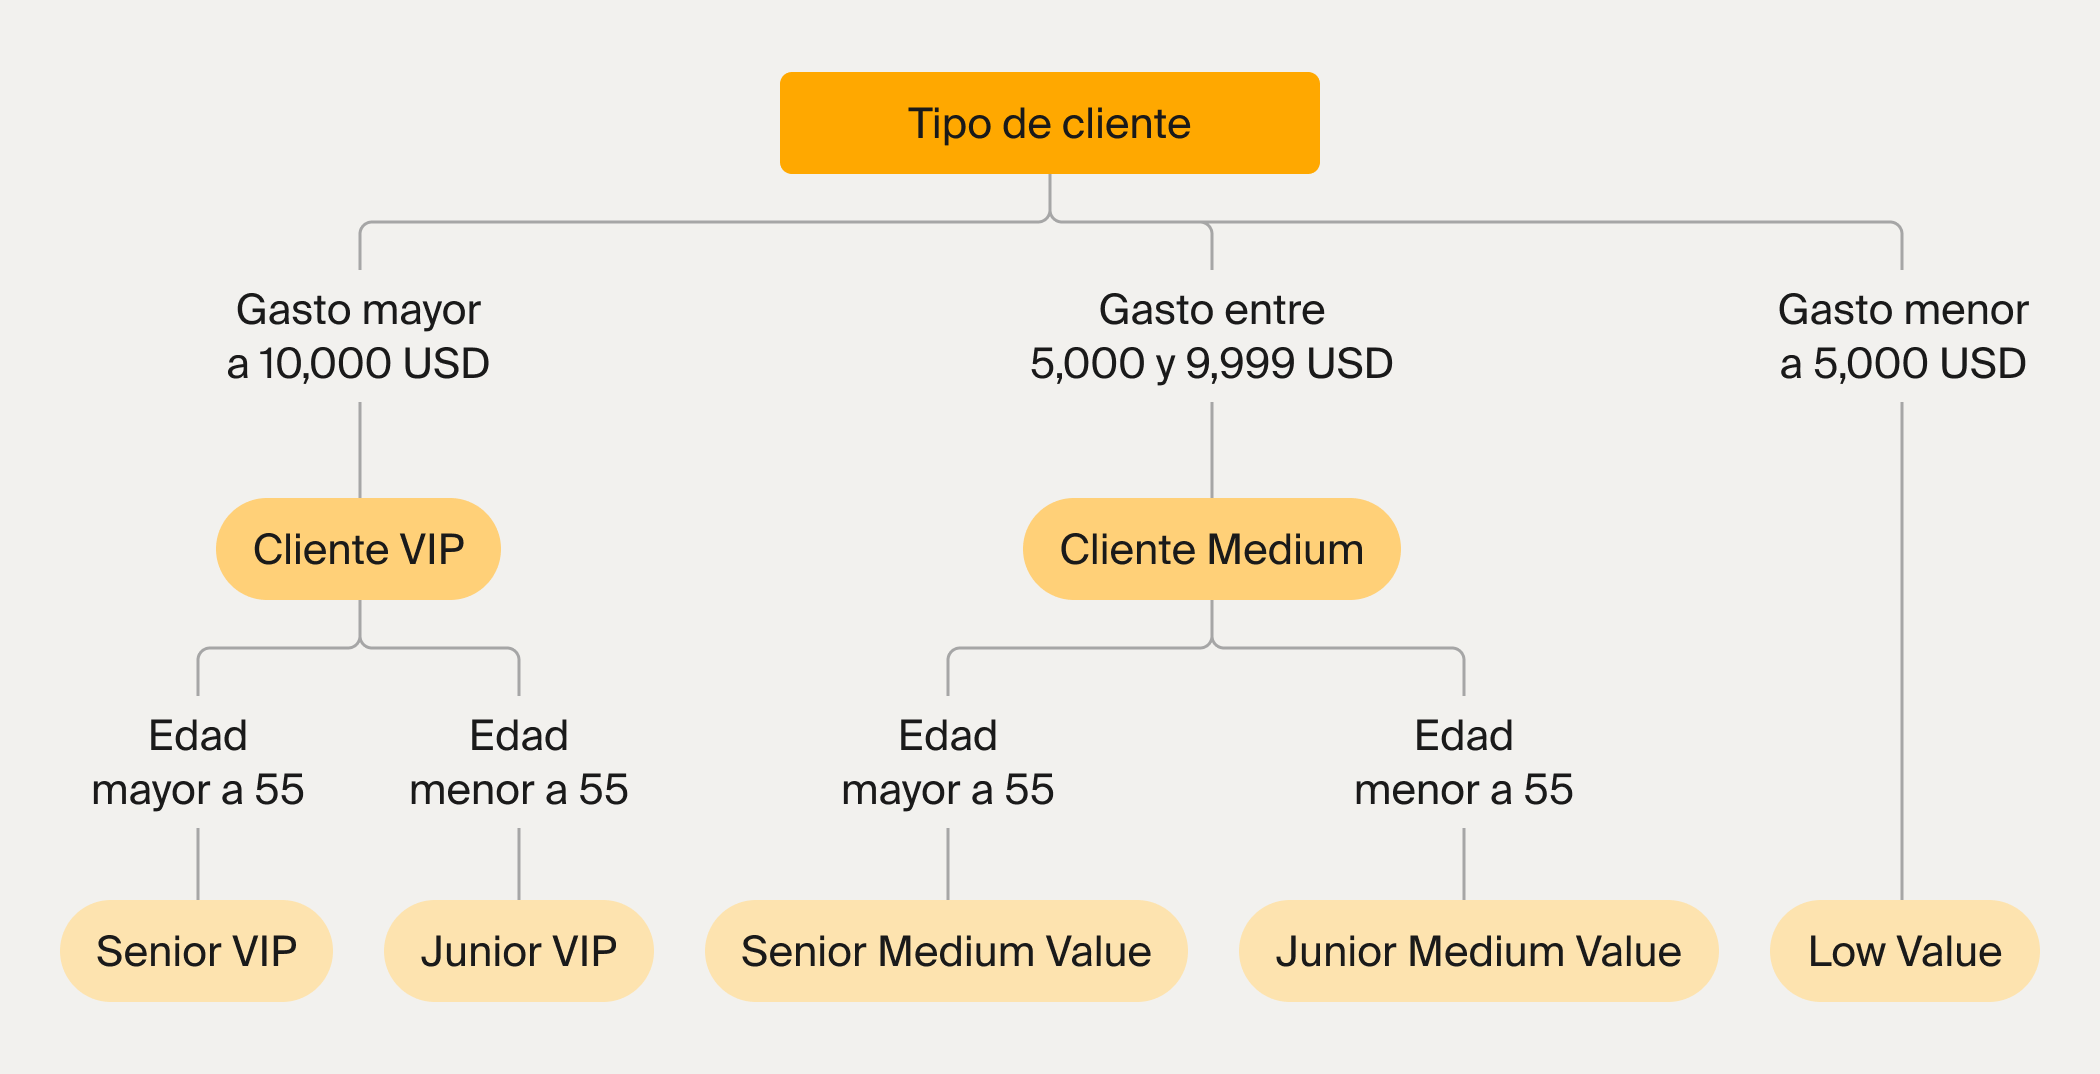

In [ ]:
import pandas as pd
import numpy as np

# Cargar datos de ejemplo
df = pd.read_csv("/datasets/everpeak_clean.csv")

# EJEMPLO 1: Usando np.where para crear una columna simple
# Crear una columna que identifique clientes "Premium" vs "Regular" basado en gasto
df["tipo_cliente_simple"] = np.where(
    df["order_value"] >= 8000,
    "Premium",
    "Regular"
)

# EJEMPLO 2: Usando función personalizada para lógica más compleja
# Función para clasificar clientes con múltiples criterios
def clasificar_cliente_detallado(row):
    edad = row['customer_age']
    gasto = row['order_value']

    # Validar datos
    if pd.isna(edad) or pd.isna(gasto):
        return "Error en Datos"

    # Lógica de clasificación compleja
    if gasto >= 10000:
        if edad >= 55:
            return "Senior VIP"
        else:
            return "Junior VIP"
    elif gasto >= 5000:
        if edad >= 55:
            return "Senior Medium"
        else:
            return "Junior Medium"
    else:
        return "Low Value"

# Aplicar la función personalizada
df["segmento_detallado"] = df.apply(clasificar_cliente_detallado, axis=1)

# Mostrar resultados
print("Comparación de métodos:")
print("\nTipo cliente simple (np.where):")
print(df["tipo_cliente_simple"].value_counts())

print("\nSegmento detallado (función personalizada):")
print(df["segmento_detallado"].value_counts())

# Ver algunos ejemplos
print("\nPrimeros 10 registros:")
print(df[["customer_age", "order_value",

ejemplo de comit